# Ecommerce Data Exploration

# Dataset Overview
- Source: Online Retail Dataset (UCI/Kaggle)
      - Prices are in GBP
- Rows: 541,909
- Columns: 8
- Date Range: 2010-12-01 to 2011-12-09 (373 days)

# Key Findings
# Data Quality Issues Found:
1. Missing CutomerIDs: 135,080 (24%)
2. Missing Descriptions: 1,454
3. Cancelled Orders: 9,288 (1.71%)
4. Negative Quantities: 10,624 (1.96%)
5. Invalid Prices: 2,517
6. Duplicates: 5,268 (0.3%)

# Business Insight
- Primarily UK-based Transactions: 495,478 (91.43%)
      - 2nd: Germany (9495)
      - 3rd: France (8557)
- Unique Products: 4,070
- Unique Customers: 4,372

# Next Steps
1. Clean data (remove cancellations, handle nulls, fix prices)
2. Design star schema
3. Build ETL pipeline

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


In [4]:
# Load the dataset 
df = pd.read_csv('../../data/raw/online_retail.csv', encoding='ISO-8859-1')

print("Dataset reloaded successfully!")
print(f"Shape: {df.shape}")

Dataset reloaded successfully!
Shape: (541909, 8)


In [5]:
# Display first 10 rows
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.69,13047.0,United Kingdom


In [6]:
# Check data types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


Description column has Null values.
Why is CustomerID data type float?

In [7]:
# Statistical summary
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


min for Quantity and UnitPrice are negative.

In [8]:
# Check for missing values
print("Missing Values Count:")
print(df.isnull().sum())
print("\n")
print("Missing Values Percentage:")
print(df.isnull().sum()/len(df)*100)

Missing Values Count:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


Missing Values Percentage:
InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.926694
Country         0.000000
dtype: float64


Description has 1454 missing values.
CustomerID has 135080 missing values.

In [9]:
# Check unique values in key columns
print(f"Unique InvoiceNo: {df['InvoiceNo'].nunique()}")
print(f"Unique StockCode: {df['StockCode'].nunique()}")
print(f"Unique CustomerID: {df['CustomerID'].nunique()}")
print(f"Unique Countries: {df['Country'].nunique()}")

Unique InvoiceNo: 25900
Unique StockCode: 4070
Unique CustomerID: 4372
Unique Countries: 38


In [10]:
# Display countries
print("Top 10 Countries by Transaction Count:")
df['Country'].value_counts().head(10)

Top 10 Countries by Transaction Count:


Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64

In [11]:
df['Country'].value_counts().sum()
print("Top country percentage")
print(f"{(df['Country'].value_counts().head(1).values[0]/df['Country'].value_counts().sum())*100:.2f}%")

Top country percentage
91.43%


In [12]:
# Check for negative quantities (returns/cancellations)
# Note to self: inner df is data that qualifies, outer df is data to be returned. By default it will return all true.
negative_qty = df[df['Quantity']<0]
print(f"Rows with negative quantities: {len(negative_qty)}")
print(f"Percentage: {len(negative_qty)/len(df)*100:.2f}%")

Rows with negative quantities: 10624
Percentage: 1.96%


In [13]:
# Check for cancellations
cancellations = df[df['InvoiceNo'].astype(str).str.startswith('C')]
print(f"Cancelled orders: {len(cancellations)}")
print(f"Percentage: {(len(cancellations))/len(df)*100:.2f}%")

Cancelled orders: 9288
Percentage: 1.71%


In [14]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

Duplicate rows: 5268


In [15]:
# Check exact column names
print("Column names in dataset:")
print(df.columns.tolist())

Column names in dataset:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [16]:
# Look at the InvoiceDate column (adjust name if needed based on Step 1)
print("First 10 InvoiceDate values:")
print(df['InvoiceDate'].head(10))
print("\nData type:")
print(df['InvoiceDate'].dtype)

First 10 InvoiceDate values:
0    12/1/2010 8:26
1    12/1/2010 8:26
2    12/1/2010 8:26
3    12/1/2010 8:26
4    12/1/2010 8:26
5    12/1/2010 8:26
6    12/1/2010 8:26
7    12/1/2010 8:28
8    12/1/2010 8:28
9    12/1/2010 8:34
Name: InvoiceDate, dtype: str

Data type:
str


In [17]:
# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Check date range
print(f"Date range: {df['InvoiceDate'].min()}) to {df['InvoiceDate'].max()}")
print(f"Total days: {(df['InvoiceDate'].max() - df['InvoiceDate'].min()).days}")

Date range: 2010-12-01 08:26:00) to 2011-12-09 12:50:00
Total days: 373


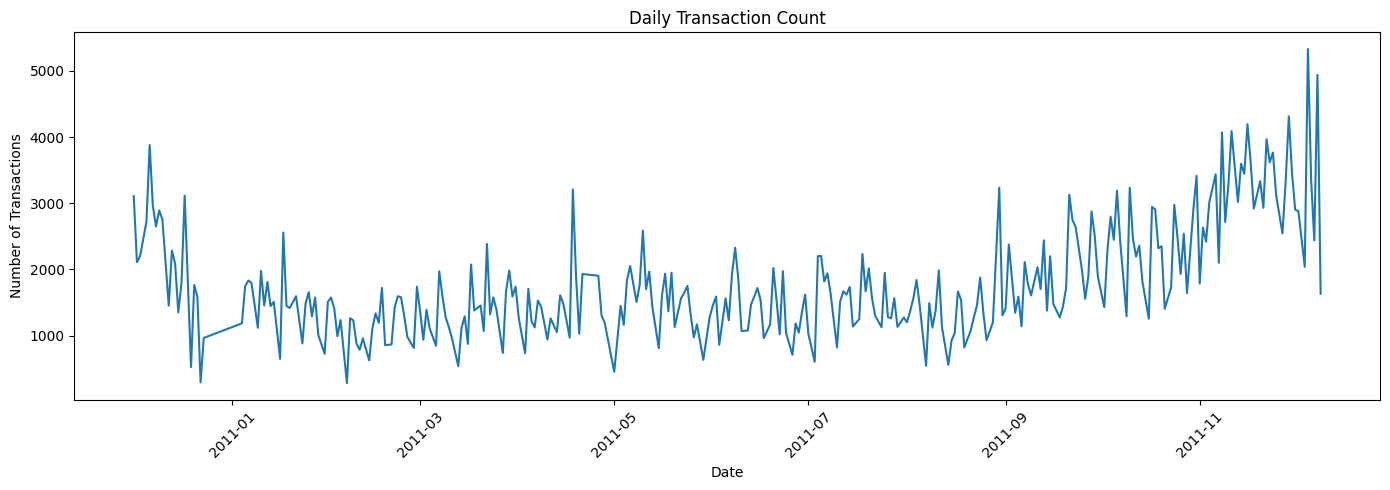

In [18]:
# Visualizations
# Transactions over time
df_daily = df.groupby(df['InvoiceDate'].dt.date).size()
plt.figure(figsize=(14, 5))
plt.plot(df_daily.index, df_daily.values)
plt.title('Daily Transaction Count')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
# Create a comprehensive data quality report
print("="*60)
print("DATA QUALITY SUMMARY REPORT")
print("="*60)
print(f"\n1. DATASET SIZE:")
print(f"   Total Rows: {len(df):,}")
print(f"   Total Columns: {len(df.columns)}")

print(f"\n2. MISSING VALUES:")
print(f"   CustomerID: {df['CustomerID'].isnull().sum():,} ({(df['CustomerID'].isnull().sum()/len(df)*100):.1f}%)")
print(f"   Description: {df['Description'].isnull().sum():,} ({(df['Description'].isnull().sum()/len(df)*100):.1f}%)")

print(f"\n3. DATA QUALITY ISSUES:")
print(f"   Negative Quantities: {len(df[df['Quantity'] < 0]):,}")
print(f"   Zero/Negative Prices: {len(df[df['UnitPrice'] <= 0]):,}")
print(f"   Cancelled Orders (C prefix): {len(df[df['InvoiceNo'].astype(str).str.startswith('C')]):,}")
print(f"   Duplicate Rows: {df.duplicated().sum():,}")

print(f"\n4. BUSINESS METRICS:")
print(f"   Unique Customers: {df['CustomerID'].nunique():,}")
print(f"   Unique Products: {df['StockCode'].nunique():,}")
print(f"   Unique Invoices: {df['InvoiceNo'].nunique():,}")
print(f"   Countries: {df['Country'].nunique()}")

print(f"\n5. DATE RANGE:")
print(f"   Start: {df['InvoiceDate'].min()}")
print(f"   End: {df['InvoiceDate'].max()}")
print(f"   Duration: {(df['InvoiceDate'].max() - df['InvoiceDate'].min()).days} days")

print("="*60)

DATA QUALITY SUMMARY REPORT

1. DATASET SIZE:
   Total Rows: 541,909
   Total Columns: 8

2. MISSING VALUES:
   CustomerID: 135,080 (24.9%)
   Description: 1,454 (0.3%)

3. DATA QUALITY ISSUES:
   Negative Quantities: 10,624
   Zero/Negative Prices: 2,517
   Cancelled Orders (C prefix): 9,288
   Duplicate Rows: 5,268

4. BUSINESS METRICS:
   Unique Customers: 4,372
   Unique Products: 4,070
   Unique Invoices: 25,900
   Countries: 38

5. DATE RANGE:
   Start: 2010-12-01 08:26:00
   End: 2011-12-09 12:50:00
   Duration: 373 days


In [20]:
df['Description'].str.len().max()

np.float64(35.0)